# RLSSM Restless Learner Tutorial

Some models need one learning rule to drive **multiple** decision parameters. Here a Rescorla–Wagner learner emits both drift (`v`) and urgency (`theta`) via `computed_param_mapping`.

See: [Basic](rlssm_basic.ipynb) · [Advanced](rlssm_advanced.ipynb)

## Setup

In [1]:

import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hssm
import ssms.rl as rl

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

hssm.set_floatX("float32", update_jax=True)


def make_participant_theta(group_theta, sds, bounds, n, rng):
    """Sample participant-level parameters around group means."""
    theta_arrays = {}
    for name, mean in group_theta.items():
        lo, hi = bounds[name]
        theta_arrays[name] = np.clip(rng.normal(mean, sds[name], size=n), lo, hi)
    true_df = pd.DataFrame(theta_arrays)
    true_df.index.name = "participant_id"
    return theta_arrays, true_df


PARTICIPANT_EFFECT_PRIOR = {
    "name": "Normal",
    "mu": {"name": "Normal", "mu": 0, "sigma": 0.1},
    "sigma": {"name": "HalfNormal", "sigma": 0.5},
}


def hierarchical_param(name, lo, hi, mu, sigma):
    """Build a truncated-normal group mean with participant random effects."""
    return hssm.Param(
        name,
        formula=f"{name} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": hssm.Prior("TruncatedNormal", lower=lo, upper=hi, mu=mu, sigma=sigma),
            "1|participant_id": PARTICIPANT_EFFECT_PRIOR,
        },
    )


def per_participant_posterior_means(idata, list_params):
  post = idata.posterior
  out = {}
  for name in list_params:
      inter = post[f"{name}_Intercept"]
      re = post[f"{name}_1|participant_id"]
      re_dim = [d for d in re.dims if d not in ("chain", "draw")][0]
      per_p = (inter + re).mean(("chain", "draw"))
      ids = [int(v) for v in re[re_dim].values]
      out[name] = pd.Series(np.asarray(per_p.values), index=ids).sort_index()
  return pd.DataFrame(out)


def plot_group_recovery(idata, list_params, group_theta, title):
    names = [f"{n}_Intercept" for n in list_params]
    summ = az.summary(idata, var_names=names, kind="stats")
    summ.index = list_params
    summ["true"] = [group_theta[n] for n in list_params]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(list_params))
    ax.errorbar(
        summ["mean"],
        y,
        xerr=[summ["mean"] - summ["hdi_3%"], summ["hdi_97%"] - summ["mean"]],
        fmt="o",
        capsize=4,
        label="posterior (intercept)",
    )
    ax.scatter(summ["true"], y, color="crimson", marker="D", zorder=5, label="true group mean")
    ax.set_yticks(y)
    ax.set_yticklabels(list_params)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()
    return summ


def run_ppc(ssms_config, observed_data, ppc_theta, random_state=0):
    """Posterior predictive simulation conditioned on observed learning history."""
    return rl.Simulator(ssms_config).simulate(
        theta=ppc_theta,
        mode="ppc",
        observed_data=observed_data,
        random_state=random_state,
    )


def plot_rt_choice_ppc(observed, ppc, title="Posterior predictive check"):
    obs_rt = observed["rt"].to_numpy()
    ppc_rt = ppc["rt"].to_numpy()
    obs_rt = obs_rt[np.isfinite(obs_rt) & (obs_rt > 0)]
    ppc_rt = ppc_rt[np.isfinite(ppc_rt) & (ppc_rt > 0)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    if len(obs_rt) and len(ppc_rt):
        axes[0].hist(obs_rt, bins=25, density=True, alpha=0.5, label="observed")
        axes[0].hist(ppc_rt, bins=25, density=True, alpha=0.5, label="ppc")
    axes[0].set_title("RT distribution")
    axes[0].legend()
    obs_resp = observed["response"]
    ppc_resp = ppc["response"]
    valid = obs_resp > -900
    obs_choice = obs_resp[valid].value_counts(normalize=True).sort_index()
    valid_ppc = ppc_resp > -900
    ppc_choice = ppc_resp[valid_ppc].value_counts(normalize=True).sort_index()
    labels = sorted(set(obs_choice.index) | set(ppc_choice.index))
    x = np.arange(len(labels))
    axes[1].bar(x - 0.2, [obs_choice.get(c, 0) for c in labels], width=0.4, label="observed")
    axes[1].bar(x + 0.2, [ppc_choice.get(c, 0) for c in labels], width=0.4, label="ppc")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_title("Response proportions")
    axes[1].legend()
    fig.suptitle(title)
    plt.show()


Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


In [2]:
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"
N_PARTICIPANTS = 10 if FULL_RUN else 4
N_TRIALS = 200 if FULL_RUN else 100
N_CHAINS = 2
N_DRAWS = 120 if FULL_RUN else 60
N_TUNE = 120 if FULL_RUN else 60
N_PPC_DRAWS = 6 if FULL_RUN else 3
RANDOM_SEED = 20260706


## Dual-output learner

In [3]:
class DualOutputRWLearner:
    """RW learner emitting drift (-> v) and urgency (-> theta)."""

    def __init__(self, initial_q=0.5, feedback_field='feedback'):
        self._initial_q = initial_q
        self._feedback_field = feedback_field

    @property
    def computed_params(self):
        return ["drift", "urgency"]

    @property
    def free_params(self):
        return ["rl_alpha", "scaler", "urgency_gain"]

    @property
    def param_bounds(self):
        return {"rl_alpha": (0.0, 1.0), "scaler": (0.001, 10.0), "urgency_gain": (0.0, 0.6)}

    @property
    def default_params(self):
        return {"rl_alpha": 0.2, "scaler": 2.0, "urgency_gain": 0.3}

    @property
    def available_backends(self):
        return ("python", "jax")

    @property
    def supports_gradient(self):
        return True

    @property
    def required_context_fields(self):
        return ["choice", "feedback"]

    def init_state(self):
        return {"q_values": np.full(2, self._initial_q, dtype=np.float64)}

    def init_jax_state(self):
        import jax.numpy as jnp
        return {"q_values": jnp.full((2,), self._initial_q)}

    def compute_python(self, state, params, context):
        q = state["q_values"]
        return {"drift": float((q[1] - q[0]) * params["scaler"]), "urgency": float(params["urgency_gain"] * (q[0] + q[1]))}

    def compute_jax(self, state, params, context):
        import jax.numpy as jnp
        q = state["q_values"]
        return {"drift": (q[1] - q[0]) * params["scaler"], "urgency": params["urgency_gain"] * (q[0] + q[1])}

    def update_python(self, state, params, context):
        choice = int(context["choice"])
        fb = float(context[self._feedback_field])
        q = np.asarray(state["q_values"], dtype=np.float64).copy()
        q[choice] += params['rl_alpha'] * (fb - q[choice])
        return {"q_values": q}

    def update_jax(self, state, params, context):
        choice = context["choice"]
        fb = context[self._feedback_field]
        q = state["q_values"]
        return {'q_values': q.at[choice].add(params['rl_alpha'] * (fb - q[choice]))}

from ssms.rl.env import Bandit

ssms_config = rl.ModelConfig(
    model_name="DualOutput_RW_Angle",
    description="RW learner with drift and urgency outputs.",
    decision_process="angle",
    learning_process=DualOutputRWLearner(),
    task_environment=Bandit.bernoulli(probabilities=[0.7, 0.3], response_labels=[-1, 1]),
    computed_param_mapping={"drift": "v", "urgency": "theta"},
)
ssms_config.validate()
assembled = ssms_config.assemble(backend="jax")
print("computed_params:", assembled.computed_params)

computed_params: ['v', 'theta']


## Simulate, bridge, fit

You supplied a model 'DualOutput_RW_Angle', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


computed SSM params: {'v', 'theta'}
User prior for '1|participant_id' on parameter 'rl_alpha' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'rl_alpha ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


User prior for '1|participant_id' on parameter 'scaler' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'scaler ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


User prior for '1|participant_id' on parameter 'urgency_gain' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'urgency_gain ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


User prior for '1|participant_id' on parameter 'a' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'a ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


...

We recommend running at least 4 chains for robust computation of convergence diagnostics


  0%|          | 0/240 [00:00<?, ?it/s]

  0%|          | 1/240 [00:00<00:27,  8.57it/s]

 67%|██████▋   | 161/240 [00:00<00:00, 881.95it/s]

100%|██████████| 240/240 [00:00<00:00, 900.27it/s]

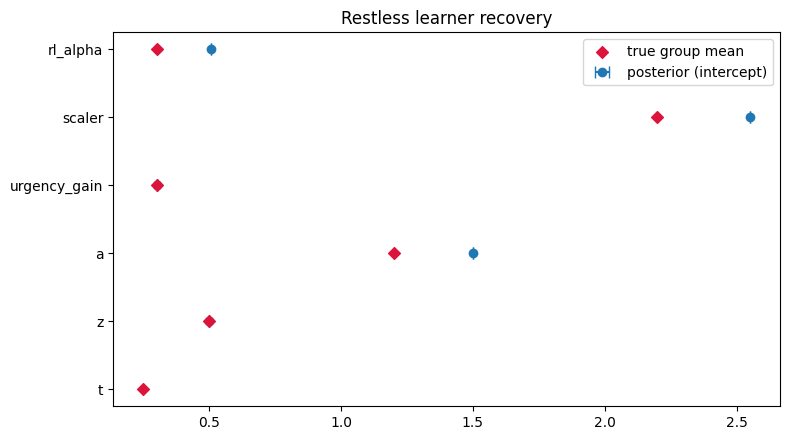

,mean,sd,hdi_3%,hdi_97%,true
rl_alpha,0.505,0.0,0.505,0.505,0.30
scaler,2.550,0.0,2.550,2.550,2.20
urgency_gain,0.300,0.0,0.300,0.300,0.30
a,1.500,0.0,1.500,1.500,1.20
z,0.500,0.0,0.500,0.500,0.50
t,NaN,NaN,NaN,NaN,0.25


In [4]:
GROUP_THETA = {
    "rl_alpha": 0.30, "scaler": 2.2, "urgency_gain": 0.30,
    "a": 1.2, "z": 0.5, "t": 0.25,
}
BOUNDS = {
    "rl_alpha": (0.01, 1.0), "scaler": (0.1, 5.0), "urgency_gain": (0.01, 0.6),
    "a": (0.3, 2.5), "z": (0.1, 0.9), "t": (0.05, 1.0),
}
SDS = {k: 0.08 for k in GROUP_THETA}
LIST_PARAMS = list(GROUP_THETA)
rng = np.random.default_rng(RANDOM_SEED)
theta_arrays, _ = make_participant_theta(GROUP_THETA, SDS, BOUNDS, N_PARTICIPANTS, rng)
data = rl.Simulator(ssms_config).simulate(
    theta=theta_arrays, n_trials=N_TRIALS, n_participants=N_PARTICIPANTS, random_state=RANDOM_SEED,
)
ssms_config.validate_data(data).raise_for_errors()
model_config = hssm.rl.RLSSMConfig.from_ssms_model(ssms_config)
print("computed SSM params:", set(model_config.ssm_logp_func.computed))
assert set(model_config.ssm_logp_func.computed) == {"v", "theta"}
model = hssm.RLSSM(
    data=data, model_config=model_config, p_outlier=0, lapse=None,
    include=[
        hierarchical_param("rl_alpha", 0.01, 1.0, 0.30, 0.15),
        hierarchical_param("scaler", 0.1, 5.0, 2.0, 0.8),
        hierarchical_param("urgency_gain", 0.0, 0.6, 0.30, 0.15),
        hierarchical_param("a", 0.3, 2.5, 1.1, 0.3),
        hierarchical_param("z", 0.1, 0.9, 0.5, 0.15),
        hierarchical_param("t", 0.05, 1.0, 0.25, 0.1),
    ],
)
idata = model.sample(draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS, cores=N_CHAINS,
                         sampler="numpyro", target_accept=0.9, random_seed=RANDOM_SEED)
plot_group_recovery(idata, LIST_PARAMS, GROUP_THETA, "Restless learner recovery")

## PPC with multiple posterior draws

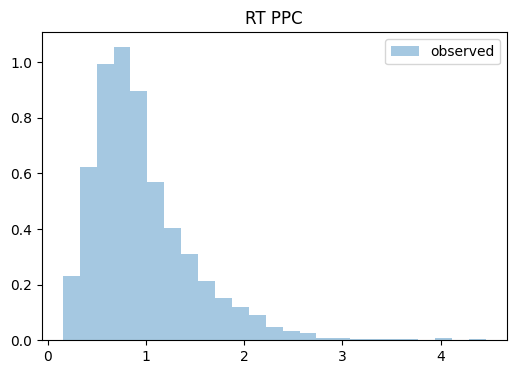

In [5]:
post = idata.posterior
ppc_rts = []
for d in range(min(N_PPC_DRAWS, post.sizes['draw'])):
    ppc_theta = {}
    for name in LIST_PARAMS:
        inter = float(post[f'{name}_Intercept'].isel(chain=0, draw=d).values)
        re = post[f'{name}_1|participant_id'].isel(chain=0, draw=d)
        ppc_theta[name] = inter + re.values
    sim = run_ppc(ssms_config, data, ppc_theta, random_state=RANDOM_SEED + d)
    ppc_rts.append(sim['rt'].to_numpy())
ppc_pool = np.concatenate(ppc_rts)
ppc_pool = ppc_pool[np.isfinite(ppc_pool) & (ppc_pool > 0)]
obs_rt = data['rt'].to_numpy()
obs_rt = obs_rt[np.isfinite(obs_rt) & (obs_rt > 0)]
fig, ax = plt.subplots(figsize=(6, 4))
if len(obs_rt):
    ax.hist(obs_rt, bins=25, density=True, alpha=0.4, label='observed')
if len(ppc_pool):
    ax.hist(ppc_pool, bins=25, density=True, alpha=0.4, label='ppc draws')
ax.legend(); ax.set_title('RT PPC'); plt.show()